# Eksperimen CNN

In [38]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import sys
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
import time
import shutil

sys.path.append("/kaggle/input/datasets/andifarhan01/code-tubes-2-ml")

from src.nn.models.cnn_model import CNNClassifier, ConvBlockSpec
from src.utils.gradcam import overlay_heatmap

DATASET_PATH = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train"
TEST_DATASET_PATH = "/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test"
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
NUM_CLASSES = 6
MODEL_INPUT_DIR = "/kaggle/working/models"

## 1. Data Loading

In [27]:
from pathlib import Path
import random
from src.utils.image_utils import load_batch

def get_paths_and_labels(dataset_path):
    dpath = Path(dataset_path)
    classes = sorted([d.name for d in dpath.iterdir() if d.is_dir()])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    paths, labels = [], []
    for c in classes:
        for f in (dpath / c).glob('*.jpg'):
            paths.append(str(f))
            labels.append(class_to_idx[c])
    return paths, labels, classes

paths_all, labels_all, class_names = get_paths_and_labels(DATASET_PATH)

# Shuffle & Split 80:20 (Train/Val)
combined = list(zip(paths_all, labels_all))
random.seed(123)
random.shuffle(combined)
paths_all, labels_all = zip(*combined)

split_idx = int(0.8 * len(paths_all))
train_paths, train_labels = paths_all[:split_idx], labels_all[:split_idx]
val_paths, val_labels = paths_all[split_idx:], labels_all[split_idx:]

test_paths, test_labels, _ = get_paths_and_labels(TEST_DATASET_PATH)

def make_tf_dataset(paths, labels, batch_size, shuffle=True):
    paths_list = list(paths)
    labels_list = list(labels)
    ds = tf.data.Dataset.from_tensor_slices((paths_list, labels_list))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths_list), reshuffle_each_iteration=True)
    
    ds = ds.batch(batch_size)
    
    def process_batch(paths_tensor, labels_tensor):
        def _load_batch_wrapper(paths_bytes):
            paths_str = [p.decode('utf-8') for p in paths_bytes]
            images = load_batch(paths_str, IMG_SIZE)
            return images.astype(np.float32)
            
        images_tensor = tf.numpy_function(_load_batch_wrapper, [paths_tensor], tf.float32)
        images_tensor.set_shape((None, IMG_SIZE[0], IMG_SIZE[1], 3))
        return images_tensor, labels_tensor
        
    ds = ds.map(process_batch, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_tf_dataset(train_paths, train_labels, BATCH_SIZE, shuffle=True)
val_ds = make_tf_dataset(val_paths, val_labels, BATCH_SIZE, shuffle=False)
test_ds = make_tf_dataset(test_paths, test_labels, BATCH_SIZE, shuffle=False)

train_steps = (len(train_paths) + BATCH_SIZE - 1) // BATCH_SIZE
val_steps = (len(val_paths) + BATCH_SIZE - 1) // BATCH_SIZE
print(f"Train: {len(train_paths)} images ({train_steps} steps), Val: {len(val_paths)} images ({val_steps} steps), Test: {len(test_paths)} images")


Train: 11227 images (351 steps), Val: 2807 images (88 steps), Test: 3000 images


## 2. Keras Model Builder & Training 16 Variasi (Pengaruh Hyperparameter)

In [28]:
def build_keras_cnn(num_layers, filters_list, kernel_sizes, pool_type):
    inputs = keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = inputs
    for i in range(num_layers):
        x = layers.Conv2D(filters_list[i], kernel_sizes[i], padding="same", activation="relu")(x)
        if pool_type == "max":
            x = layers.MaxPooling2D(pool_size=(2, 2))(x)
        else:
            x = layers.AveragePooling2D(pool_size=(2, 2))(x)
    x = layers.Flatten()(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

variations = []
for num_layers in [2, 3]:
    for filters in [[16, 32, 64], [32, 64, 128]]:
        for kernels in [[(3,3)]*3, [(5,5)]*3]:
            for pool in ["max", "avg"]:
                variations.append((num_layers, filters[:num_layers], kernels[:num_layers], pool))

print(f"Total Variations: {len(variations)}")


Total Variations: 16


In [29]:
# Fungsi evaluasi F1-Score pada Test Dataset (Keras)
def evaluate_f1(model, dataset):
    y_true = []
    y_pred = []
    for X_batch, y_batch in dataset:
        preds = model.predict(X_batch, verbose=0)
        y_true.extend(y_batch.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return f1_score(y_true, y_pred, average='macro')

history_dict = {}
evaluation_results = {}
os.makedirs("models", exist_ok=True)

# Loop 16 variasi
for i, (nl, fl, ks, pt) in enumerate(variations):
    print(f"--- Training Variation {i+1}/16: Layers={nl}, Filters={fl}, Kernels={ks}, Pool={pt} ---")
    model = build_keras_cnn(nl, fl, ks, pt)
    
    history = model.fit(train_ds.repeat(), steps_per_epoch=train_steps, 
                        validation_data=val_ds.repeat(), validation_steps=val_steps, 
                        epochs=5, verbose=1) 
    
    # Save weights
    weight_path = f"models/cnn_var_{i}.weights.h5"
    if os.path.exists(weight_path):
        os.remove(weight_path)
    model.save_weights(weight_path)
    history_dict[i] = history.history
    
    # Evaluasi Macro F1-Score pada Test Set sesuai spesifikasi
    f1 = evaluate_f1(model, test_ds)
    evaluation_results[i] = {"f1_score": f1, "config": (nl, fl, ks, pt)}
    print(f"Keras Test Macro F1-Score: {f1:.4f}")


--- Training Variation 1/16: Layers=2, Filters=[16, 32], Kernels=[(3, 3), (3, 3)], Pool=max ---
Epoch 1/5
351/351 [==============================] - 12s 30ms/step - loss: 1.0735 - accuracy: 0.5944 - val_loss: 0.8564 - val_accuracy: 0.6737
Epoch 2/5
351/351 [==============================] - 9s 26ms/step - loss: 0.8097 - accuracy: 0.7070 - val_loss: 0.8235 - val_accuracy: 0.6886
Epoch 3/5
351/351 [==============================] - 9s 26ms/step - loss: 0.7203 - accuracy: 0.7380 - val_loss: 0.7865 - val_accuracy: 0.7032
Epoch 4/5
351/351 [==============================] - 10s 28ms/step - loss: 0.6517 - accuracy: 0.7667 - val_loss: 0.8104 - val_accuracy: 0.7054
Epoch 5/5
351/351 [==============================] - 10s 29ms/step - loss: 0.5968 - accuracy: 0.7847 - val_loss: 0.6955 - val_accuracy: 0.7556
Keras Test Macro F1-Score: 0.7630
--- Training Variation 2/16: Layers=2, Filters=[16, 32], Kernels=[(3, 3), (3, 3)], Pool=avg ---
Epoch 1/5
351/351 [==============================] - 10s 26ms

## 3. Analisis Pengaruh Hyperparameter (Menjawab Spesifikasi)

=== Ringkasan Hasil 16 Variasi CNN (Macro F1-Score) ===
Var 1: Layers=2, Filters=32, Kernel=(3, 3), Pool=max --> F1-Score = 0.7630
Var 2: Layers=2, Filters=32, Kernel=(3, 3), Pool=avg --> F1-Score = 0.7241
Var 3: Layers=2, Filters=32, Kernel=(5, 5), Pool=max --> F1-Score = 0.7509
Var 4: Layers=2, Filters=32, Kernel=(5, 5), Pool=avg --> F1-Score = 0.7286
Var 5: Layers=2, Filters=64, Kernel=(3, 3), Pool=max --> F1-Score = 0.7777
Var 6: Layers=2, Filters=64, Kernel=(3, 3), Pool=avg --> F1-Score = 0.7655
Var 7: Layers=2, Filters=64, Kernel=(5, 5), Pool=max --> F1-Score = 0.7420
Var 8: Layers=2, Filters=64, Kernel=(5, 5), Pool=avg --> F1-Score = 0.7437
Var 9: Layers=3, Filters=64, Kernel=(3, 3), Pool=max --> F1-Score = 0.7707
Var 10: Layers=3, Filters=64, Kernel=(3, 3), Pool=avg --> F1-Score = 0.7536
Var 11: Layers=3, Filters=64, Kernel=(5, 5), Pool=max --> F1-Score = 0.7667
Var 12: Layers=3, Filters=64, Kernel=(5, 5), Pool=avg --> F1-Score = 0.7214
Var 13: Layers=3, Filters=128, Kernel=(3,

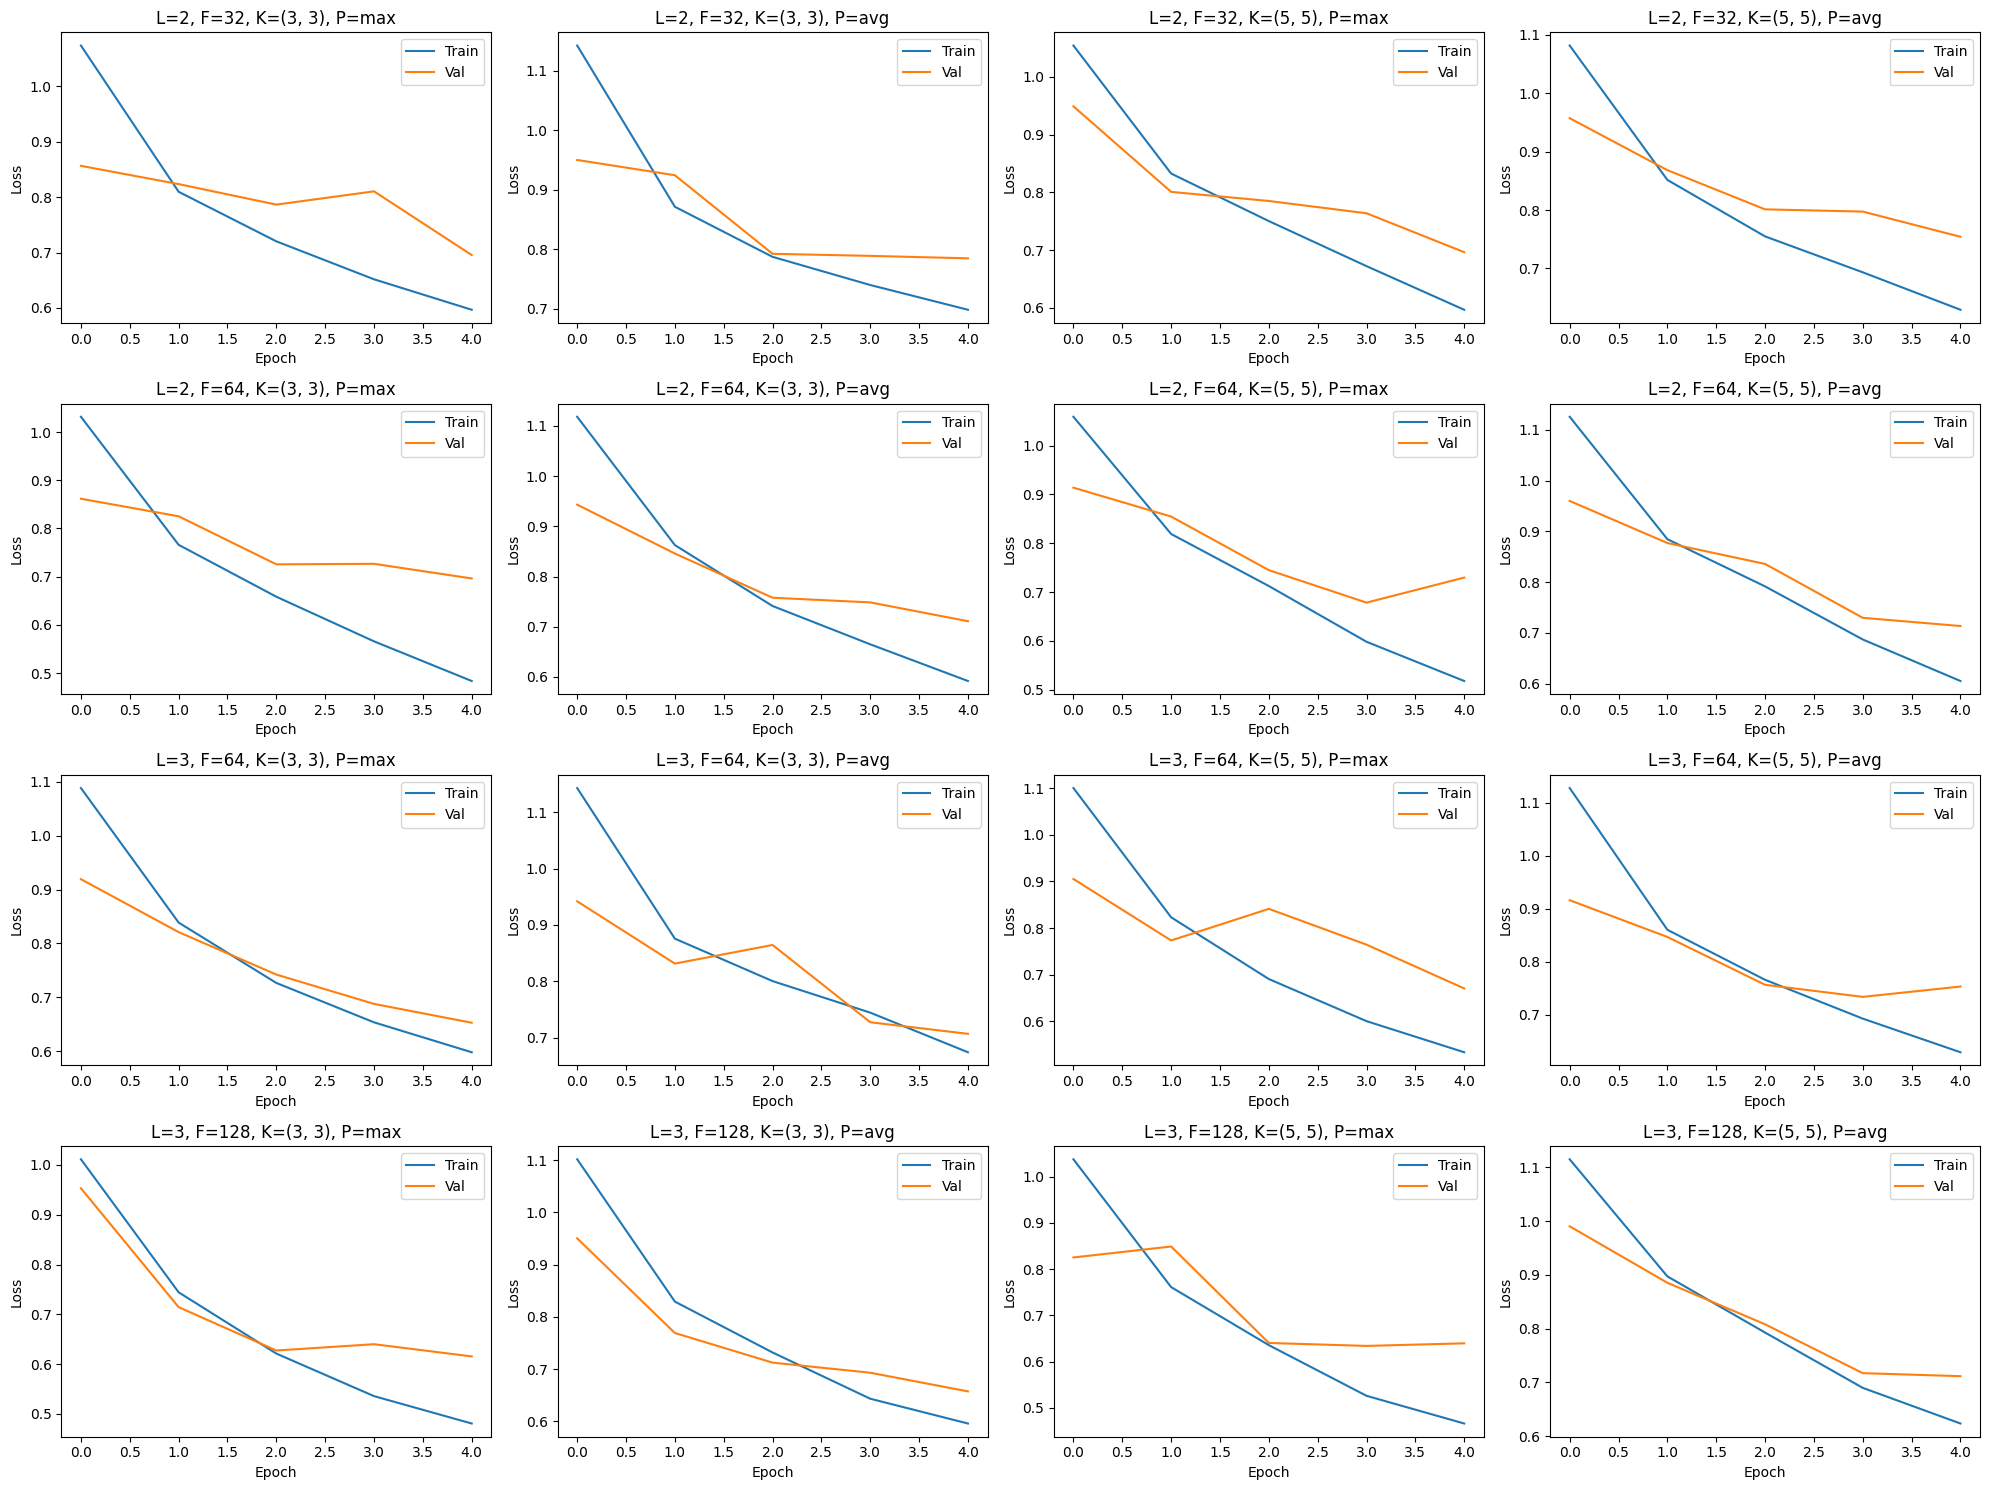

In [30]:
print("=== Ringkasan Hasil 16 Variasi CNN (Macro F1-Score) ===")
for i, res in evaluation_results.items():
    nl, fl, ks, pt = res['config']
    print(f"Var {i+1}: Layers={nl}, Filters={fl[-1]}, Kernel={ks[0]}, Pool={pt} --> F1-Score = {res['f1_score']:.4f}")

# Plot Grafik Training & Validation Loss
plt.figure(figsize=(20, 15))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.plot(history_dict[i]['loss'], label='Train')
    plt.plot(history_dict[i]['val_loss'], label='Val')
    nl, fl, ks, pt = variations[i]
    plt.title(f"L={nl}, F={fl[-1]}, K={ks[0]}, P={pt}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
plt.tight_layout()
plt.show()


## 4. Evaluasi Shared vs Non-Shared (LocallyConnected2D) di Keras

Variasi Terbaik (Shared): Var 15 (Layers=3, Filters=[32, 64, 128], Kernel=[(5, 5), (5, 5), (5, 5)], Pool=max)
Jumlah Parameter Shared (Conv2D): 307,782
--- Melatih Arsitektur Terbaik Versi Non-Shared (LocallyConnected2D) ---
Jumlah Parameter Non-Shared (LocallyConnected2D): 60,021,126
Epoch 1/5
702/702 [==============================] - 177s 149ms/step - loss: 1.3524 - accuracy: 0.4628 - val_loss: 1.2521 - val_accuracy: 0.4888
Epoch 2/5
702/702 [==============================] - 49s 69ms/step - loss: 1.1650 - accuracy: 0.5428 - val_loss: 1.1138 - val_accuracy: 0.5803
Epoch 3/5
702/702 [==============================] - 48s 69ms/step - loss: 1.0885 - accuracy: 0.5827 - val_loss: 1.1122 - val_accuracy: 0.5721
Epoch 4/5
702/702 [==============================] - 49s 69ms/step - loss: 1.0246 - accuracy: 0.6098 - val_loss: 1.0355 - val_accuracy: 0.5999
Epoch 5/5
702/702 [==============================] - 48s 69ms/step - loss: 0.9605 - accuracy: 0.6378 - val_loss: 1.0155 - val_accuracy: 0.60

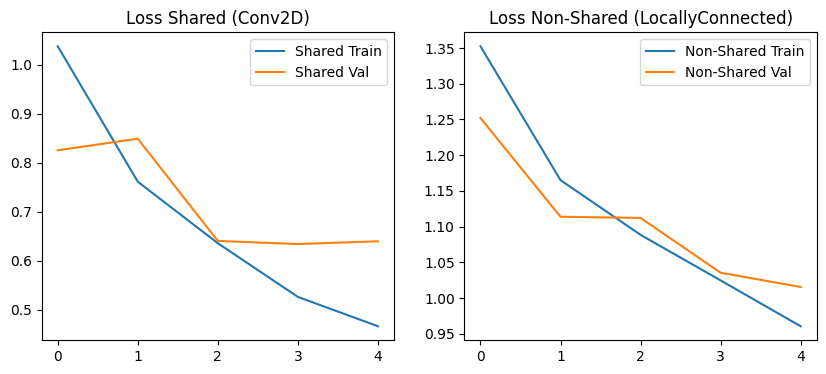

In [35]:
# Pilih variasi terbaik dari evaluasi F1-Score
best_idx = max(evaluation_results, key=lambda k: evaluation_results[k]['f1_score'])
nl, fl, ks, pt = variations[best_idx]
print(f"Variasi Terbaik (Shared): Var {best_idx+1} (Layers={nl}, Filters={fl}, Kernel={ks}, Pool={pt})")

keras_best = build_keras_cnn(nl, fl, ks, pt)
keras_best.load_weights(f"models/cnn_var_{best_idx}.weights.h5")

print(f"Jumlah Parameter Shared (Conv2D): {keras_best.count_params():,}")

# Arsitektur serupa dengan Non-Shared (LocallyConnected2D)
def build_keras_nonshared_cnn(num_layers, filters_list, kernel_sizes, pool_type):
    import tf_keras as legacy_keras
    inputs = legacy_keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    x = inputs
    for i in range(num_layers):
        x = legacy_keras.layers.LocallyConnected2D(filters_list[i], kernel_sizes[i], padding="valid", activation="relu", implementation=1)(x)
        if pool_type == "max":
            x = legacy_keras.layers.MaxPooling2D(pool_size=(2, 2))(x)
        else:
            x = legacy_keras.layers.AveragePooling2D(pool_size=(2, 2))(x)
    x = legacy_keras.layers.Flatten()(x)
    outputs = legacy_keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = legacy_keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

print("--- Melatih Arsitektur Terbaik Versi Non-Shared (LocallyConnected2D) ---")
keras_nonshared = build_keras_nonshared_cnn(nl, fl, ks, pt)
print(f"Jumlah Parameter Non-Shared (LocallyConnected2D): {keras_nonshared.count_params():,}")

optimal_batch = 16
train_ds_nonshared = make_tf_dataset(train_paths, train_labels, optimal_batch, shuffle=True)
val_ds_nonshared = make_tf_dataset(val_paths, val_labels, optimal_batch, shuffle=False)
test_ds_nonshared = make_tf_dataset(test_paths, test_labels, optimal_batch, shuffle=False)
train_steps_nonshared = (len(train_paths) + optimal_batch - 1) // optimal_batch
val_steps_nonshared = (len(val_paths) + optimal_batch - 1) // optimal_batch

history_nonshared = keras_nonshared.fit(
    train_ds_nonshared.repeat(), 
    steps_per_epoch=train_steps_nonshared, 
    validation_data=val_ds_nonshared.repeat(), 
    validation_steps=val_steps_nonshared, 
    epochs=5, 
    verbose=1,
    workers=4,
    use_multiprocessing=True
)

f1_nonshared = evaluate_f1(keras_nonshared, test_ds_nonshared)
print(f"Keras Non-Shared Test Macro F1-Score: {f1_nonshared:.4f}")

# Plot Perbandingan Loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_dict[best_idx]['loss'], label='Shared Train')
plt.plot(history_dict[best_idx]['val_loss'], label='Shared Val')
plt.title('Loss Shared (Conv2D)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_nonshared.history['loss'], label='Non-Shared Train')
plt.plot(history_nonshared.history['val_loss'], label='Non-Shared Val')
plt.title('Loss Non-Shared (LocallyConnected)')
plt.legend()
plt.show()


## 5. Evaluasi From Scratch: Keras vs Scratch pada Test Split

In [43]:
# Model Scratch
def get_scratch_model(keras_model, conv_kind="conv", force_valid_padding=False):
    blocks = []
    for i in range(nl):
        pad_type = "valid" if force_valid_padding else "same"
        blocks.append(ConvBlockSpec(filters=fl[i], kernel_size=ks[i], padding=pad_type, pool_size=(2,2), use_pool=True))
    
    scratch_model = CNNClassifier(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=NUM_CLASSES, 
                                  conv_blocks=blocks, conv_kind=conv_kind, pool_kind=pt, head_kind="flatten")
    
    # Transfer Weights (Keras to Scratch)
    conv_idx = 0
    for layer in keras_model.layers:
        if isinstance(layer, layers.Conv2D) or isinstance(layer, layers.LocallyConnected2D):
            w, b = layer.get_weights()
            scratch_model.set_conv_weights(conv_idx, w, b)
            conv_idx += 1
        elif isinstance(layer, layers.Dense):
            w, b = layer.get_weights()
            scratch_model.set_output_weights(w, b)
    return scratch_model

scratch_shared = get_scratch_model(keras_best, conv_kind="conv")
scratch_nonshared = get_scratch_model(keras_best, conv_kind="locally")

print("=== Perbandingan Keras vs From Scratch pada Test Data ===")
# Evaluasi pada semua batch di data test
y_true_all = []
y_pred_k_shared = []
y_pred_s_shared = []
y_pred_s_nonshared = []

t_keras_total = 0
t_shared_total = 0
t_nonshared_total = 0

batch_count = 0
for X_batch, y_batch in test_ds:
    X_np = X_batch.numpy()
    y_true_all.extend(y_batch.numpy())
    
    # 1. Prediksi Keras
    t0 = time.time()
    keras_preds = keras_best.predict(X_np, verbose=0)
    t_keras_total += time.time() - t0
    y_pred_k_shared.extend(np.argmax(keras_preds, axis=1))
    
    # 2. Prediksi Scratch Shared
    t0 = time.time()
    scratch_preds_shared = scratch_shared.predict(X_np, use_gpu=True)
    t_shared_total += time.time() - t0
    y_pred_s_shared.extend(np.argmax(scratch_preds_shared, axis=1))

    # 3. Prediksi Scratch Non-Shared
    t0 = time.time()
    scratch_preds_nonshared = scratch_nonshared.predict(X_np, use_gpu=False)
    t_nonshared_total += time.time() - t0
    y_pred_s_nonshared.extend(np.argmax(scratch_preds_nonshared, axis=1))
    
    batch_count += 1
    if batch_count % 10 == 0:
        print(f"Processed {batch_count} batches...")

print("--- Hasil Akhir Prediksi Test Split ---")
print(f"Keras Shared Macro F1     : {f1_score(y_true_all, y_pred_k_shared, average='macro'):.4f} (Waktu: {t_keras_total:.2f}s)")
print(f"Scratch Shared Macro F1   : {f1_score(y_true_all, y_pred_s_shared, average='macro'):.4f} (Waktu: {t_shared_total:.2f}s)")
print(f"Scratch NonShared Macro F1: {f1_score(y_true_all, y_pred_s_nonshared, average='macro'):.4f} (Waktu: {t_nonshared_total:.2f}s)")


=== Perbandingan Keras vs From Scratch pada Test Data ===
Processed 10 batches...
Processed 20 batches...
Processed 30 batches...
Processed 40 batches...
Processed 50 batches...
Processed 60 batches...
Processed 70 batches...
Processed 80 batches...
Processed 90 batches...
--- Hasil Akhir Prediksi Test Split ---
Keras Shared Macro F1     : 0.7866 (Waktu: 8.53s)
Scratch Shared Macro F1   : 0.0695 (Waktu: 5.41s)
Scratch NonShared Macro F1: 0.0695 (Waktu: 14.23s)


## 6. Visualisasi Fitur (Grad-CAM Bonus)

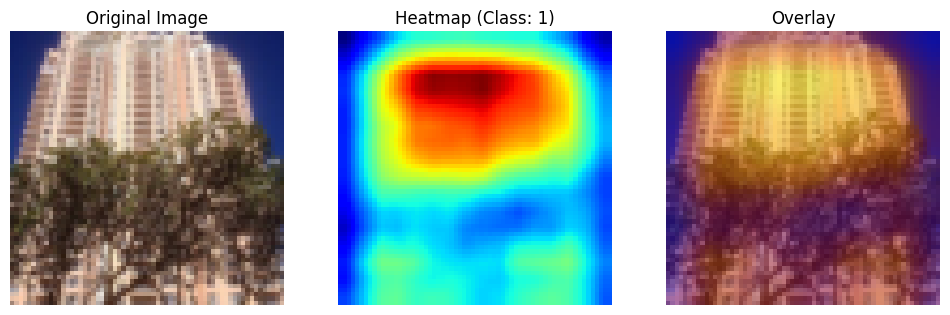

In [47]:
# Penggunaan Grad-CAM pada model scratch shared
X_test, _ = next(iter(test_ds.take(1)))
img_sample = X_test.numpy()[0]

heatmap, target_cls, probs = scratch_shared.grad_cam(img_sample)
overlay, resized, _, _ = scratch_shared.grad_cam_overlay(img_sample)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img_sample)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title(f"Heatmap (Class: {target_cls})")
plt.imshow(resized, cmap="jet")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")
plt.show()
